# Ejercicios Prácticos Módulo VI

La entrega será la copia de este notebook resuelta con el nombre del participante en el nombre del archivo.
* Recuerde copiar este notebook y trabajar sobre la copia.

## Opción 1

Realizar los 3 siguientes ejercicios, documentar paso a paso como es el proceso, imprimir el accuraccy y las imagenes resultantes de cada uno de ellos.

### Ejercicio 1

Hacer un clasificador de perros y gatos, definimos las imagenes de 180x180x1 y el número de clases es igual a 2, usar una arquitectura tipo lenet (Accuracy debe ser mayor al 70% para que se tome como completo).

#### Preparar ambiente

Durante la clase los ejercicios se realizaron utilizando keras y tensorflow, en mi caso tensorflow no es compatible con mi GPU que tiene un CUDA 13.2, estuve leyendo la documentación y tensorflow al parecer solo es compatible máximo con CUDA 12.x áun no tiene soporte para CUDA 13.x. Tomando en cuenta esto y para que yo pueda aprovechar el uso de mi GPU en el entrenamiento de los ejercicios, utilizaré PyTorch.

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
!pip install torchinfo

Con el siguiente fragmento de código se puede comprobar si nuestro ambiente esta detectando la GPU.

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: NVIDIA GeForce RTX 2070 SUPER


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchinfo import summary

Con este comando descargaremos el dataset de las imagenes de Perros y Gatos que utilizaremos para entrenar nuestro modelo

In [8]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0  10.6M      0  0:01:13  0:01:13 --:--:-- 11.4MM      0  0:01:14  0:00:33  0:00:41 11.3M


Debemos descomprimir el archivo del dataset.

In [10]:
!unzip -q kagglecatsanddogs_5340.zip

In [3]:
!ls PetImages

Cat  Dog


El dataset de las imagenes que se descargo puede ser que contenga imagenes dañadas, por lo tanto es importante realizar una limpieza de nuestro dataset.
En este caso revisaremos imagen por imagen para saber cuales pudieran estar dañadas y en este caso las eliminamos, ya que no nos serán útiles.

In [12]:
num_deleted = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()
        
        if not is_jfif:
            num_deleted += 1
            # Borramos la imagen corrupta
            os.remove(fpath)

print(f"Imagenes eliminadas: {num_deleted}")

Imagenes eliminadas: 1590


El total de Imagenes eliminadas fue de: 1590, es por eso que es importante hacer una limpieza a nuestro dataset.

In [32]:
image_size = (180, 180) # Las instrucciones del ejercicio nos solicita definir las imagenes de 180x180
batch_size = 256 # Definimos el tamaño de nuestro batch, este realmente puede ser cualquiera, pero para aprovechar mi GPU será de 256

#Definimos nuestra semilla de aleatoridad.
seed = 26 # Me gusta el 26 jeje
torch.manual_seed(seed)
np.random.seed(seed)
generator = torch.Generator().manual_seed(seed)


# Definimos las transformaciones que se aplicarán a cada imagen de nuestro dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Como el ejercicio pide que sea 180x180x1 el x1 del final hace referencia a escalas grises, actualmente nuestras imagenes son RGB x3
    transforms.Resize(image_size), # Redimensionamos todas las imagenesa a el tamaño definido 180x180
    transforms.ToTensor() # Se normalizan las imagenes automáticamente, tenemos un rango de [0, 255] y lo pasa a un rango de [0,1]
])

# Cargamos nuestro dataset
dataset = datasets.ImageFolder(
    root="PetImages", # Nombre de la carpeta que contiene el dataset, se toma cada subcarpeta que tengamso como una clase, en nuestro caso "Cats" -> Clase 0 y "Dogs" -> Clase 1
    transform=transform # Se aplican las transformaciones definidas anteriormente
)

train_size = int(0.8 * len(dataset)) # Definimos el tamaño de entrenamiento: 80%
val_size = len(dataset) - train_size # Defininimos el tamaño de validación: 20%

# Dividimos nuestro dataset de forma aleatoria: 80% para entrenamiento y 20% para validación
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)

# Creamos los DataLoader de entrenamiento y validación, estos permiten iterar sobre nuestro dataset en batches (128)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) # Para el caso del entrenamiento mezclamos los datos en cada época 
                                                                         # (Para que no aprenda primero puros Gatos y luego puros Perros)
val_loader = DataLoader(val_ds, batch_size=batch_size)  # Para la validación no es necesario hacer una mezcla

In [33]:
# Definimos nuestro modelo para PyTorch, en clase lo definimos con keras.Sequential(), se me hace más intuitivo como lo maneja keras para ser sinceros.
# Para PyTorch se tiene que definir una clase en este caso definiremos nuestra CNN

class CNN(nn.Module):
    def __init__(self):
        # Definimos la clase padre
        super(CNN, self).__init__()

        # Capas convolucionales
        # Para crear la capa se utiliza Conv2d que recibe los siguientes parametros: Conv2d(entrada, salida, tamaño_kernel)

        self.conv1 = nn.Conv2d(1, 32, 3)    # Primera capa: Recibe un canal (Ya que estamos trabajando con imagenes en escalas grises) y produce 32 mapas de características. 
        self.conv2 = nn.Conv2d(32, 64, 3)   # Segunda capa: 32 -> 64 filtros
        self.conv3 = nn.Conv2d(64, 128, 3)  # Tercera capa: 64 -> 128 filtros
        self.conv4 = nn.Conv2d(128, 128, 3) # Cuarta capa: 128 -> 128 filtros

        self.pool = nn.MaxPool2d(2, 2)      # Capa de pooling (reduce el tamaño espacial), en clase vimos que puede ser de 2x2, 3x3, etc. Pero 2x2 en este caso es funcional

        self.fc1 = nn.Linear(128 * 9 * 9, 128)  # Capa densa, esta capa recibe el tensor aplanado (flatten)
        self.dropout = nn.Dropout(0.5)      # Con el dropout apagamos aleatoriamente neuronas para evitar overfitting
        self.fc2 = nn.Linear(128, 2)        # Capa final, esperamos una salida de 2 (Cat y Dog)

    # Definimos el orden de ejecución y sus funciones de activación para cada capa.
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Aplicamos la primera capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv2(x))) # Aplicamos la segunda capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv3(x))) # Aplicamos la tercera capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = self.pool(F.relu(self.conv4(x))) # Aplicamos la cuarta capa de convolución, con una función de activación ReLU y realizamos el pooling
        x = torch.flatten(x, 1) # Se realiza un flatten para aplanar y obtener un vector.
        x = F.relu(self.fc1(x)) # Aplicamos la capa densa, con una función de activación ReLU, aquí ya no hacemos pooling
        x = self.dropout(x) # Aplicamos dropout
        x = self.fc2(x) # Esta es nuestra capa final que tendra nuesta salida de 2 (Cat y Dog), en PyTorch no se acostumbra a poner la función de activiación Softmax en este flujo
                        # Posteriomente en el entrenamiento se utiliza CrossEntropyLoss que internamente realiza un Softmax.

        return x

In [36]:
# Y ahora si, la razón por la cual estoy utilizando PyTorch es para aprovechar mi GPU en el entrenamiento.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Detectamos si existe una GPU (CUDA)

model = CNN().to(device) # Enviamos el modelo para que se ejecute en CPU o GPU (En mi caso se va al GPU)

summary(model, input_size=(batch_size, 1, 180, 180)) # En keras teniamos algo como model.summary() para ver la info, en este caso se utiliza summary de torchinfo

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [256, 2]                  --
├─Conv2d: 1-1                            [256, 32, 178, 178]       320
├─MaxPool2d: 1-2                         [256, 32, 89, 89]         --
├─Conv2d: 1-3                            [256, 64, 87, 87]         18,496
├─MaxPool2d: 1-4                         [256, 64, 43, 43]         --
├─Conv2d: 1-5                            [256, 128, 41, 41]        73,856
├─MaxPool2d: 1-6                         [256, 128, 20, 20]        --
├─Conv2d: 1-7                            [256, 128, 18, 18]        147,584
├─MaxPool2d: 1-8                         [256, 128, 9, 9]          --
├─Linear: 1-9                            [256, 128]                1,327,232
├─Dropout: 1-10                          [256, 128]                --
├─Linear: 1-11                           [256, 2]                  258
Total params: 1,567,746
Trainable params: 1,567,746
Non-trainab

In [37]:
criterion = nn.CrossEntropyLoss() # Función de pérdida: Combina Softmax + Cálculo de error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Para ajustar los pesos del modelo durante el entrenamiento, utilizaremos Adam (En clase se dijo que era el bueno)

In [ ]:
# Este fragmento de código sirve para entrenar nuestro modelo

epochs = 20 # Definimos el número de épocas

# En keras se utilizaba algo como model.fit(), en pytorch se tiene que hacer manualmente el entrenamiento
for epoch in range(epochs):
    model.train() # Debemos indicar que el modelo esta en entrenamiento para que active las capas especiales como Dropout
    
    # Inicializamos variables para obtener el loss y accuracy
    running_loss = 0.0
    correct = 0
    total = 0

    # Recorremos los datos en batches (train_loader contiene la info del batch)
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Aprovechamos una vez más la GPU enviandolo a que se ejecute ahí
        optimizer.zero_grad()   # Se reinician los gradientes
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels)   # Calculamos la pérdida comparando las predicciones contras las etiquetas reales

        loss.backward() # Calcula los gradientes de la pérdida (Backpropagation)
        optimizer.step()  # Actualziza los pesos del modelo usando el optimizador Adam

        running_loss += loss.item() # Acumulamos la pérdida del batch

        _, predicted = torch.max(outputs, 1) # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor (Cats -> 0 o Dogs -> 1)
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración (Lo normal es que sea de 256 por que es el tamaño de nuestro batch)
        correct += (predicted == labels).sum().item()  # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos

    accuracy = correct / total  # Calculamos el accuracy total de la época

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.4f}") # Imprimimos resultados de la época

Epoch 1, Loss: 50.2062, Accuracy: 0.5658
Epoch 2, Loss: 47.1361, Accuracy: 0.6403
Epoch 3, Loss: 43.7998, Accuracy: 0.6867
Epoch 4, Loss: 39.2479, Accuracy: 0.7384
Epoch 5, Loss: 35.7005, Accuracy: 0.7714
Epoch 6, Loss: 33.4577, Accuracy: 0.7874
Epoch 7, Loss: 30.6893, Accuracy: 0.8091
Epoch 8, Loss: 29.0430, Accuracy: 0.8211
Epoch 9, Loss: 27.1193, Accuracy: 0.8361
Epoch 10, Loss: 25.2024, Accuracy: 0.8473
Epoch 11, Loss: 23.3787, Accuracy: 0.8615
Epoch 12, Loss: 21.7522, Accuracy: 0.8696
Epoch 13, Loss: 19.5021, Accuracy: 0.8878
Epoch 14, Loss: 18.2364, Accuracy: 0.8969
Epoch 15, Loss: 16.1215, Accuracy: 0.9089
Epoch 16, Loss: 15.0811, Accuracy: 0.9170
Epoch 17, Loss: 13.7383, Accuracy: 0.9239
Epoch 18, Loss: 12.5492, Accuracy: 0.9333
Epoch 19, Loss: 10.9263, Accuracy: 0.9419
Epoch 20, Loss: 8.8850, Accuracy: 0.9532


In [ ]:
# Este fragmento de código es para tomar el dataset de validación y obtener el accuracy y perdida de nuestro modelo, al enfrentarse a imagenes que no conoce.

model.eval() # Ahora debemos poner nuestro modelo en modo de evaluación

# Iniciamos variables para obtener el loss y accuracy
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad(): # Desactivamos el cálculo de gradientes
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device) # Enviamos los datos a la GPU para aprovechar su rendimiento
        outputs = model(images) # Obtenemos las predicciones del modelo (salidas)
        loss = criterion(outputs, labels) # Calculamos la pérdida 
        val_loss += loss.item() * images.size(0)  # Acumlamos la pérdida 
        _, predicted = torch.max(outputs, 1)   # Obtenemos la prediccion, devuelve en predicted el indice que tenga mayor valor (Cats -> 0 o Dogs -> 1)
        total += labels.size(0) # Contamos cuantas imagenes se procesaron en esta iteración (Lo normal es que sea de 256 por que es el tamaño de nuestro batch)
        correct += (predicted == labels).sum().item() # Comparamos las predicciones con las etiquetas para saber cuantas predicciones fueron correctas y sumamos


val_loss = val_loss / total # Calculamos la pérdida total del dataset de validación
accuracy = correct / total # Calculamos el accuracy total del dataset de validación

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {accuracy:.4f}")

Validation loss: 0.5416
Validation accuracy: 0.8349


#### Interpretación de los resultados obtenidos:

<b>* Validation loss de 0.5416</b>: Este entre más bajo sea es mejor, lo que podemos observar es que hay oportunidad para mejorar nuestro modelo, pero lo que indica es que tanto se acercan las predicciones del modelo a las predicciones reales. 

<b>* Validation accuracy de 0.8349</b>: Este entre más cercano al 1 mejor, pero lo que indica es que porcentaje de imágenes fueron correctamente clasificadas en el dataset de validación. Para la tarea se solicitaba que fuera arriba de 70% por lo que obtener un 83% es bastante bueno.

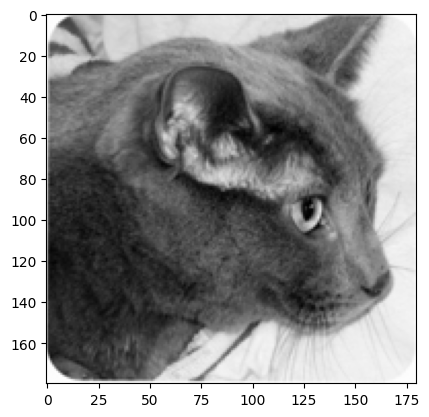

Esta imagen es 99.89% Gato y 0.11% Perro.


In [47]:
# Este fragmento de código es para realizar una prueba de predicción de una imagen con nuestro modelo.

# Cargar imagen en escala de grises con convert("L")
img = Image.open("PetImages/Cat/6779.jpg").convert("L")
img = img.resize((180, 180))

# Mostrar imagen
plt.imshow(img, cmap="gray")
plt.show()

# Preprocesar la imagen para poder ingresarla al modelo
img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)

# Predicción
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1) # Aquí lo que queremos es saber la predicción y no como tal saber el loss y accuracy. Por lo tanto metemos la función softmax a la salida de nuestra red.

# Convertir las probabilidades a numpy para asignarlas
probs = probs.cpu().numpy()[0]

gato_prob = probs[0]
perro_prob = probs[1]

print(f"Esta imagen es {100 * gato_prob:.2f}% Gato y {100 * perro_prob:.2f}% Perro.")

### Ejercicio 2

Crea una red que clasifique el dataset stanford_dogs usando el extractor del VGG16
1. Definir un modelo que tenga el VGG16 como entrada
2. Aplanar el vector de rasgos
3. Definir una o varias capas densas con 120 clases de salida
4. Entrenar el modelo

### Ejercicio 3

YOLO
* Hacer un dataset de 100 imágenes con 3 clases
* Entrenar el modelo usando el dataset ya sea con la implementación de keras o la de ultralytics, se recomienda ultralytics.
* Entrenar el modelo y mostrar los resultados.

## Opción 2

Realiza una implementación que resuleva una problemática del día a día utilizando algunos de los modelos vistos en clase.
Ejemplo:
* Detector de mascotas
* Clasificador de ropa
* Detector de vehículos para una cochera
* Etc

Te puedes apoyar de la IA para que te ayude con las partes de código que no entiendas, con la condición de que eres responsable por la entrega (si la IA se equivoca no es excusa para cambiar la clasificación)
Debes poner un planteamiento, el código bien documentando, así como los resultados con una imagen que tu hayas tomado.